# 1. Scenario Definition and Problem Framing

This notebook starts from the system under study rather than from an abstract parameter sweep. The question is: given a fixed 3GPP-compliant 100 MHz micro-cell deployment and a small set of PA options on each transmit chain, how should the network allocate PHY resources so that active PA energy is minimized while user service requirements are still met?


## 1. Problem statement

The rest of the notebook set follows this line of argument:

- Mobile-network energy use matters at system level.
- The PA is a large and controllable share of that energy use.
- Mixed-PA hardware on one PHY chain has already been demonstrated in compliant NR systems.
- The remaining thesis question is operational: when demand arrives, which resource allocation should the network choose so that active PA energy is as low as possible?


## 1.1 Fixed scenario to scheduler contract

The code path in this notebook is intentionally short. One fixed 100 MHz radio preset is resolved into a concrete deployment, paired with the measured PA set, and reduced to the scheduler-facing contract that later notebooks store and assign.


In [5]:
import sys
from pathlib import Path
from IPython.display import display

repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent

for path in (repo_root / "notebooks", repo_root / "src"):
    resolved = str(path.resolve())
    if resolved not in sys.path:
        sys.path.insert(0, resolved)

from helpers.scenario_definition_helpers import ScenarioDefinitionHelpers

# Notebook-wide visual identity: change this once to rerun under the other institutional theme.
helper = ScenarioDefinitionHelpers(theme="aalto_elec")
helper.display_contract_flowchart()

artifacts = helper.build_artifacts(
    distance_m=200.0,
    required_rate_bps=120e6,
)


<IPython.core.display.Javascript object>

In [2]:
display(
    helper.render_table(
        artifacts.radio_assumptions,
    )
)


group,assumption,value
Deployment,Scenario,3GPP-compliant micro cell in band n78
Deployment,Carrier frequency,3.5 GHz
Deployment,Channel bandwidth,100 MHz
Propagation,Path-loss model,umi_sc_nlos
Propagation,BS / UE heights,10.0 m / 1.5 m
Propagation,Antenna gains,"8.0 dB TX, 0.0 dB RX"
Link budget,Thermal noise density,-174 dBm/Hz
Link budget,LNA noise figure,5.0 dB
Link budget,Implementation loss,3.0 dB
Link budget,Shadow margin,4.0 dB


## 2. Hardware options and compliant resource space

The study assumes one fixed 100 MHz carrier on one 4-MIMO sub-array with four active transmit chains. Each chain can use one of two measured NR PA families. The resource-allocation view does not keep every internal solver column. It keeps only the scheduler-facing axes that still matter when users are later matched to stored operating rows.


In [3]:
display(
    helper.render_table(
        artifacts.pa_characteristics[
            ["pa_id", "scenario_label", "pa_name", "p_max_w", "p_idle_w", "eta_max"]
        ],
        formats={
            "p_max_w": "{:.1f}",
            "p_idle_w": "{:.2f}",
            "eta_max": "{:.2f}",
        },
    )
)


pa_id,scenario_label,pa_name,p_max_w,p_idle_w,eta_max
0,8W PA,Bae et al. NR,7.9,3.84,0.42
1,4W PA,QPA9942,1.8,0.42,0.35


## 3. PA behavior and the bridge to candidate generation

The measured PA curves explain why this allocation problem matters. The energy cost changes across operating points, and the PA choice interacts with occupied bandwidth, spatial layers, and required power. The final table in this notebook is therefore not yet a solution. It defines the search envelope that later notebooks turn into stored candidate rows.


(<Figure size 940x540 with 2 Axes>,
 (<Axes: xlabel='Average PA output power (dBm)', ylabel='Gain (dB)'>,
  <Axes: ylabel='PAE (%)'>))

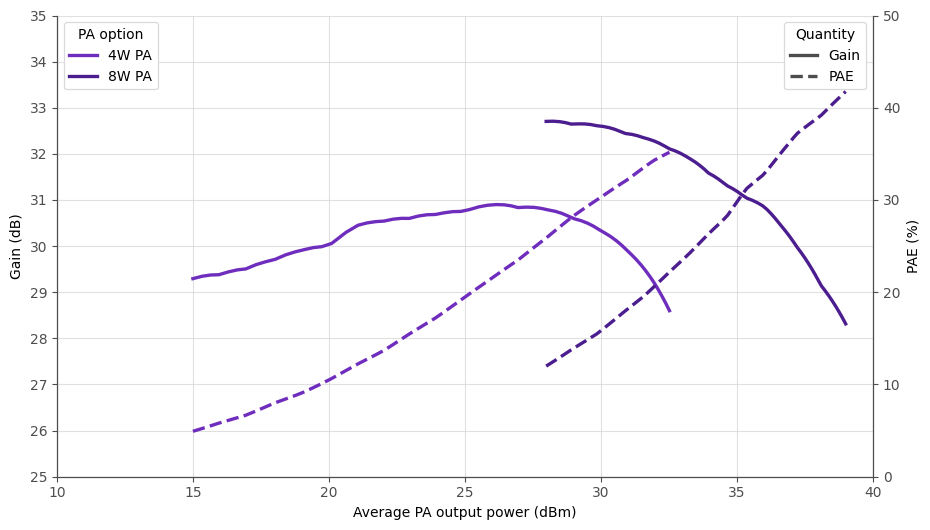

In [4]:
helper.plot_pa_gain_and_pae(artifacts.pa_curve_table)


This notebook fixes the scenario and the decision space. The next notebook moves from this fixed setting to the candidate space itself, and the notebook after that turns the full-frame feasible rows into the precomputed table that later notebooks assign to users.
